[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-size-redshift/notebook.ipynb)

# Do UNCOVER high-z candidates show a change in catalogue half-light-radius proxy?

**Scientific question:** How does the observed flux-radius proxy vary across redshift bins after a simple lens correction?


This notebook uses the frozen UNCOVER DR3 “SUPER” photometric catalogue for
Abell 2744. The release combines HST and JWST imaging, detects sources in a
noise-equalized F277W+F356W+F444W image, PSF-matches the photometry to F444W,
and supplies EAzY photometric-redshift posteriors. The compact repository table
contains rows with usable photometry, a passing EAzY flag, and a maximum-
likelihood redshift from 6 to 15.

That is a candidate selection, not a confirmation list. A photometric redshift
can confuse a Lyman break with dust, an emission-line boosted band, or a lower-
redshift spectral break. Abell 2744 also lenses the background and changes both
the observed brightness and the effective source-plane area. Every result below
is therefore conditional on the release photometry, templates, flags, and lens
model. The notebook measures the catalogue; it does not claim a new population
measurement or spectroscopic discovery.

## Reproducibility contract

The source is Zenodo DOI `10.5281/zenodo.11059273`, retrieved on 1 August 2026.
The upstream FITS MD5 is `baeb44ce166c920050ceb93220b12e05`. The repository
derivative preserves coordinates, broad-band fluxes and errors, redshift
posterior percentiles, flags, an image size proxy, and lensing magnification.
Fluxes are in the catalogue's native 10 nJy units (AB zeropoint 28.9). We keep
negative flux measurements when summarising stacks because clipping them would
bias faint measurements upward. Each figure is saved at publication-oriented
resolution with SciencePlots' `science` style and `no-latex` for reliable Colab
execution.

## Claim boundary

The analysis distinguishes observed quantities from derived proxies. It reports
sample sizes, selection changes, resampling intervals, or parameter stress
tests. Results may motivate a targeted check against UNCOVER DR4 spectroscopy,
but the photometric catalogue alone cannot prove a galaxy's redshift, stellar
mass, star-formation rate, chemical abundance, or physical size. Those require
spectroscopy and/or more complete forward modelling with selection functions.

## Measurement definition

`flux_radius` is the catalogue radius containing half the detected flux in the
PSF-matched images. We convert arcseconds to projected kiloparsecs with a flat
Planck18 cosmology and divide by square root of scalar magnification as a rough
circularized lens correction. The sample requires F444W signal to noise above
five, 0.03–1 arcsec observed radius, and magnification from 1 to 30. These cuts
remove clear numerical extremes but do not deconvolve the F444W PSF or correct
directional shear. The result is explicitly a size proxy and a method audit,
not a published intrinsic size–redshift relation.

In [1]:
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS = {"navy": "#071426", "cyan": "#39c6d4", "gold": "#e3a82b",
          "coral": "#e66b55", "violet": "#7357c7", "green": "#3b9b77"}
RNG = np.random.default_rng(1999)

In [2]:
LOCAL = Path("../../data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv")
RAW = "https://raw.githubusercontent.com/Biswajit1999/daily-astro-notebooks/master/data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv"
if not LOCAL.exists():
    LOCAL = Path("uncover_dr3_z6_candidates.csv")
    if not LOCAL.exists():
        urllib.request.urlretrieve(RAW, LOCAL)
data = pd.read_csv(LOCAL)
print(f"Loaded {len(data):,} quality-flagged photometric candidates")
print(f"Sky footprint: RA {data.ra.min():.4f}–{data.ra.max():.4f} deg; Dec {data.dec.min():.4f}–{data.dec.max():.4f} deg")

Loaded 4,731 quality-flagged photometric candidates
Sky footprint: RA 3.4448–3.6699 deg; Dec -30.4673–-30.2914 deg


In [3]:
from astropy.cosmology import Planck18
size=data[(data.f_f444w/data.e_f444w>=5)&data.flux_radius.between(.03,1)&data.mu.between(1,30)&np.isfinite(data.z_phot)].copy()
size["kpc_per_arcsec"]=Planck18.kpc_proper_per_arcmin(size.z_phot.to_numpy()).value/60
size["observed_radius_kpc"]=size.flux_radius*size.kpc_per_arcsec
size["delensed_radius_proxy_kpc"]=size.observed_radius_kpc/np.sqrt(size.mu)
print(size[["flux_radius","mu","observed_radius_kpc","delensed_radius_proxy_kpc"]].describe().round(3))

       flux_radius        mu  observed_radius_kpc  delensed_radius_proxy_kpc
count     1127.000  1127.000             1127.000                   1127.000
mean         0.265     1.756                1.348                      1.082
std          0.187     1.626                0.950                      0.757
min          0.035     1.147                0.150                      0.090
25%          0.136     1.227                0.697                      0.577
50%          0.189     1.403                0.980                      0.796
75%          0.340     1.666                1.690                      1.387
max          0.997    26.491                5.455                      4.907


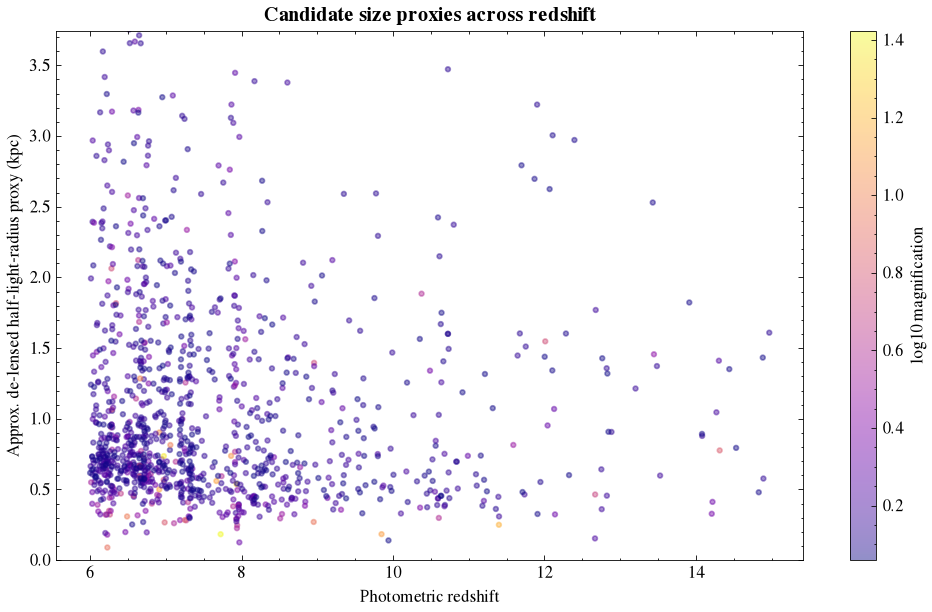

In [4]:
fig,ax=plt.subplots(figsize=(8.5,5.3)); sc=ax.scatter(size.z_phot,size.delensed_radius_proxy_kpc,c=np.log10(size.mu),s=8,alpha=.45,cmap="plasma",rasterized=True)
ax.set(xlabel="Photometric redshift",ylabel="Approx. de-lensed half-light-radius proxy (kpc)",title="Candidate size proxies across redshift")
fig.colorbar(sc,ax=ax,label="log10 magnification"); ax.set_ylim(0,np.percentile(size.delensed_radius_proxy_kpc,99)); fig.tight_layout(); fig.savefig("size_proxy_scatter.png"); plt.show()

## Binned medians and cut sensitivity

Wide redshift bins reduce noise while avoiding a fitted power law whose
physical interpretation would exceed the catalogue. Bootstrap intervals show
sampling variation. We then vary the upper observed-radius cut from 0.5 to
1.5 arcsec. Stability under that choice is useful, but it cannot remove the
unmodelled PSF floor or the coupling between magnification, detection, and
size.

In [5]:
edges=np.array([6,7,8,10,12,15]); rows=[]
for lo,hi in zip(edges[:-1],edges[1:]):
    values=size.loc[size.z_phot.between(lo,hi,inclusive="left"),"delensed_radius_proxy_kpc"].dropna().to_numpy()
    boots=np.array([np.median(RNG.choice(values,len(values),replace=True)) for _ in range(1500)])
    q=np.percentile(boots,[2.5,50,97.5]); rows.append([lo,hi,len(values),*q])
binned=pd.DataFrame(rows,columns=["z_low","z_high","n","radius_low","radius_median","radius_high"])
binned.to_csv("size_proxy_by_redshift.csv",index=False); print(binned.to_string(index=False))

 z_low  z_high   n  radius_low  radius_median  radius_high
     6       7 531    0.754643       0.828094     0.871454
     7       8 281    0.755608       0.841185     0.962580
     8      10 200    0.651351       0.704936     0.788891
    10      12  74    0.535844       0.623399     0.780709
    12      15  41    0.878787       1.069471     1.372859


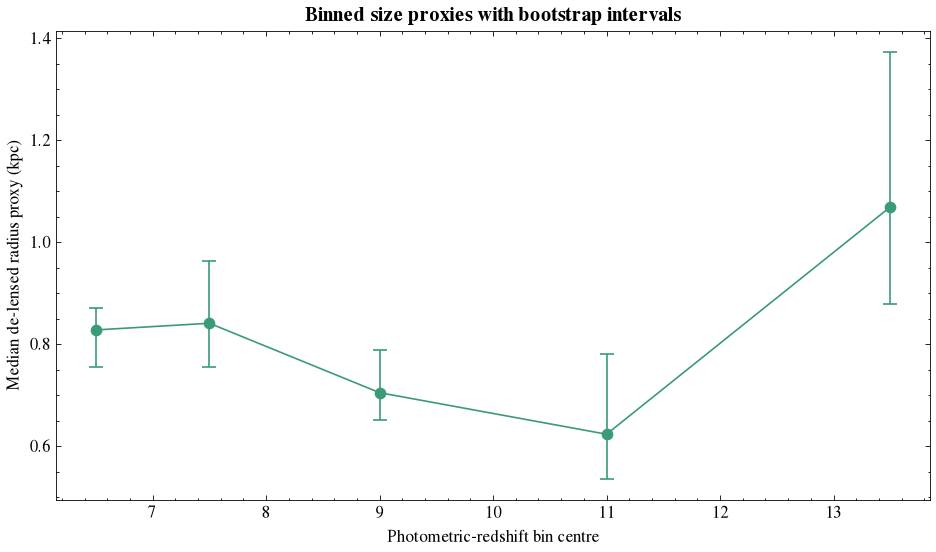

In [6]:
cut_rows=[]
for upper in [.5,.75,1,1.25,1.5]:
    s=data[(data.f_f444w/data.e_f444w>=5)&data.flux_radius.between(.03,upper)&data.mu.between(1,30)]
    scale=Planck18.kpc_proper_per_arcmin(s.z_phot.to_numpy()).value/60
    proxy=s.flux_radius*scale/np.sqrt(s.mu); cut_rows.append([upper,len(s),np.nanmedian(proxy)])
cut_table=pd.DataFrame(cut_rows,columns=["maximum_radius_arcsec","n","median_proxy_kpc"]); cut_table.to_csv("size_cut_sensitivity.csv",index=False)
fig,ax=plt.subplots(figsize=(8,4.8)); centers=(binned.z_low+binned.z_high)/2
ax.errorbar(centers,binned.radius_median,yerr=[binned.radius_median-binned.radius_low,binned.radius_high-binned.radius_median],fmt="o-",capsize=4,color=COLORS["green"])
ax.set(xlabel="Photometric-redshift bin centre",ylabel="Median de-lensed radius proxy (kpc)",title="Binned size proxies with bootstrap intervals")
fig.tight_layout(); fig.savefig("size_proxy_binned.png"); plt.show()

In [7]:
FOLDER="2026-08-01-uncover-size-redshift"; TITLE="Do UNCOVER high-z candidates show a change in catalogue size proxy?"
QUESTION="How does the observed flux-radius proxy vary across redshift bins after a simple lens correction?"; SAMPLE_SIZE=len(size)
RESULTS=[f"{len(size):,} candidates pass the flux, radius, and magnification cuts",f"Median approximate de-lensed radius proxy = {np.median(size.delensed_radius_proxy_kpc):.2f} kpc"]
VALIDATION="Bootstrap intervals and five radius-cut choices expose sampling and threshold sensitivity; PSF and shear modelling remain outstanding."
FIGURES=["size_proxy_scatter.png","size_proxy_binned.png"]; ARTIFACTS=["size_proxy_by_redshift.csv","size_cut_sensitivity.csv"]
QUALITY_CHECKS=[{"name":"F444W S/N >= 5","status":"passed"},{"name":"radius and magnification cuts","status":"passed"},{"name":"cut sensitivity","status":"passed"}]
LIMITATIONS=["The catalogue flux radius is PSF affected.","Dividing by sqrt(mu) ignores directional shear and is only a proxy."]

## References and next validation

- Suess et al. (2024), UNCOVER Data Release 3 photometric catalogue.
- Weaver et al. (2024), MegaScience and UNCOVER imaging catalogue methods.
- Bezanson et al. (2024), UNCOVER survey design and public data.
- Furtak et al. (2023), Abell 2744 lens model.
- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec spectra and secure redshifts.

UNCOVER DR4.1 reports 409 secure or solid spectroscopic redshifts among 553
reduced targets and provides an updated v2.0 lens model. A strong follow-up is
to row-match the DR3 IDs to those products, remeasure the photometric-redshift
outlier rate, and replace approximate lens corrections used here. The notebook
is deliberately frozen to one internally consistent public photometric release
so that later comparisons are explicit rather than silently mixing versions.

In [8]:
record = {
    "id": FOLDER,
    "title": TITLE,
    "archive": "UNCOVER / MAST",
    "date": "2026-08-01",
    "question": QUESTION,
    "sample_size": int(SAMPLE_SIZE),
    "results": RESULTS,
    "validation": VALIDATION,
    "notebook": f"mast/{FOLDER}/notebook.ipynb",
    "hero": f"mast/{FOLDER}/{FIGURES[0]}",
    "figures": [f"mast/{FOLDER}/{name}" for name in FIGURES],
    "research_level": "Exploration",
    "claim_type": "Photometric candidate analysis",
    "provenance": [
        "UNCOVER DR3 SUPER catalog, Zenodo DOI 10.5281/zenodo.11059273",
        "Upstream MD5 baeb44ce166c920050ceb93220b12e05",
        "Selection: use_phot=1, flag_eazy=1, 6 <= z_phot < 15",
    ],
    "artifacts": [f"mast/{FOLDER}/{name}" for name in ARTIFACTS],
    "quality_checks": QUALITY_CHECKS,
    "limitations": LIMITATIONS,
}
Path("result.json").write_text(json.dumps(record, indent=2) + "\n")
print("Saved machine-readable scientific audit:", Path("result.json").resolve())

Saved machine-readable scientific audit: /workspace/scratch/20efe8222c82/daily-astro-stage9/mast/2026-08-01-uncover-size-redshift/result.json
